Análise de Vendas com python, pandas e matplotlib

In [296]:
# Import das bibliotecas e DataFrame
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/vendas.csv', encoding = 'utf -8') # Banco de dados de vendas entre 2024-2025

In [297]:
# Explorando df
df.info()
df.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 1420 entries, 0 to 1419
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_venda        1420 non-null   int64  
 1   data            1420 non-null   str    
 2   cliente         1412 non-null   str    
 3   produto         1415 non-null   str    
 4   categoria       1420 non-null   str    
 5   quantidade      1420 non-null   int64  
 6   preco_unitario  1420 non-null   float64
 7   regiao          1408 non-null   str    
 8   canal_venda     1412 non-null   str    
 9   desconto        1408 non-null   float64
dtypes: float64(2), int64(2), str(6)
memory usage: 111.1 KB


,id_venda,data,cliente,produto,categoria,quantidade,preco_unitario,regiao,canal_venda,desconto
0,1,2024-01-26,Yasmin Santos,Monitor 24,Eletronicos,1,799.9,Sul,Loja Fisica,0.05
1,2,2024-08-16,Diego Barbosa,Luminaria LED,Casa,1,69.9,Norte,Marketplace,0.05
2,3,2025-11-23,Yasmin Almeida,Monitor 24,Eletronicos,1,799.9,Sul,Marketplace,0.00
3,4,2025-08-27,Larissa Silva,Teclado Mecanico,Eletronicos,1,249.9,Centro-Oeste,Loja Fisica,0.00
4,5,2024-04-05,Felipe Oliveira,Notebook Pro 14,Eletronicos,2,4200.0,Nordeste,Online,0.00
5,6,2025-09-08,Lucas Almeida,Webcam HD,Eletronicos,2,174.5,Nordeste,Loja Fisica,0.05
6,7,2025-10-27,William Almeida,Mesa Compacta,Moveis,2,662.9,Nordeste,Online,0.20
7,8,2024-08-13,Marcos Ferreira,Curso SQL Basico,Cursos,2,129.9,Centro-Oeste,Online,0.10
8,9,2024-01-07,Eduarda Barbosa,Garrafa Termica,Casa,3,59.9,Norte,Marketplace,0.00
9,10,2024-12-14,Henrique Costa,Curso SQL Basico,Cursos,-1,132.5,Sudeste,Loja Fisica,0.00


In [298]:
# Verificando e limpando duplicadas
df.duplicated().sum()
df = df.drop_duplicates()

# Converte coluna data para tipo data
df['data'] = pd.to_datetime(df['data'], errors = 'coerce')

# Organizando nulos
df.isna().sum() # Conferindo
df['desconto'] = df['desconto'].fillna(0) # Definindo valores nulos da coluna desconto com ZERO
df['canal_venda'] = df['canal_venda'].fillna('desconhecido') # Definindo valores nulos da coluna canal_venda para desconhecido
df['regiao'] = df['regiao'].fillna('nao informado') # Definindo valores nulos da regiao para desconhecido

# Confere se há mais nulos
df.isna().sum()
df = df.dropna(subset=['produto', 'cliente', 'data']) # Remove linhas produto, cliente ou data que mostram nulos

# Definindo palavras em forma minúscula e removendo espaços inúteis de colunas
colunas_texto = ['cliente', 'produto', 'categoria', 'regiao', 'canal_venda']
for i in colunas_texto:
    df[i] = df[i].str.lower().str.strip()

# Mantém apenas o que é positivo e maior que zero
df = df[df['quantidade'] > 0]
df = df[df['preco_unitario'] > 0]

# Remove linhas com desconto menor que 0% ou maior que 100%
df = df[(df['desconto'] >= 0) & (df['desconto'] <= 1)]

# Analisando se há categorias com e sem acentos
df['categoria'].value_counts() # Há acentos em eletrônicos e móveis
# Remove acentos de 'categoria'
df['categoria'] = df['categoria'].replace({
    'eletrônicos': 'eletronicos',
    'móveis': 'moveis',
})
# Remove acentos de 'produtos'
df['produto'] = df['produto'].replace({
    'teclado mecânico': 'teclado mecanico',
    'caneca térmica': 'caneca termica',
    'curso sql básico': 'curso sql basico',
    'garrafa térmica': 'garrafa termica'
})

df['categoria'].value_counts() # Sem acentos em categoria
df['produto'].value_counts() # Sem acentos em produtos

# Salvando o df limpo
df_limpo = df
df['produto'].value_counts()

produto
luminaria led           84
teclado mecanico        80
livro python pratico    80
mochila executiva       77
headset gamer           76
camiseta dry fit        74
caneca termica          73
ssd 1tb                 70
webcam hd               69
planner 2025            69
mouse sem fio           68
monitor 24              64
curso sql basico        64
tenis runner            63
mesa compacta           61
tablet lite             60
smartphone x            59
garrafa termica         54
cadeira office          51
notebook pro 14         50
Name: count, dtype: int64

In [299]:
# Criando colunas necessárias para deixar a exibição do Dataframe mais entuitivo

df_limpo['faturamento_bruto'] = df_limpo['quantidade'] * df_limpo['preco_unitario']
df_limpo['valor_desconto'] = df_limpo['faturamento_bruto'] * df_limpo['desconto']
df_limpo['faturamento_liquido'] = df_limpo['faturamento_bruto'] - df_limpo['valor_desconto']
df_limpo['mes'] = df_limpo['data'].dt.month
df_limpo['ano'] = df_limpo['data'].dt.year

df_limpo.info()
df_limpo

<class 'pandas.DataFrame'>
Index: 1346 entries, 0 to 1406
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id_venda             1346 non-null   int64         
 1   data                 1346 non-null   datetime64[us]
 2   cliente              1346 non-null   str           
 3   produto              1346 non-null   str           
 4   categoria            1346 non-null   str           
 5   quantidade           1346 non-null   int64         
 6   preco_unitario       1346 non-null   float64       
 7   regiao               1346 non-null   str           
 8   canal_venda          1346 non-null   str           
 9   desconto             1346 non-null   float64       
 10  faturamento_bruto    1346 non-null   float64       
 11  valor_desconto       1346 non-null   float64       
 12  faturamento_liquido  1346 non-null   float64       
 13  mes                  1346 non-null   int32       

,id_venda,data,cliente,produto,categoria,quantidade,preco_unitario,regiao,canal_venda,desconto,faturamento_bruto,valor_desconto,faturamento_liquido,mes,ano
0,1,2024-01-26,yasmin santos,monitor 24,eletronicos,1,799.9,sul,loja fisica,0.05,799.9,39.995,759.905,1,2024
1,2,2024-08-16,diego barbosa,luminaria led,casa,1,69.9,norte,marketplace,0.05,69.9,3.495,66.405,8,2024
2,3,2025-11-23,yasmin almeida,monitor 24,eletronicos,1,799.9,sul,marketplace,0.00,799.9,0.000,799.900,11,2025
3,4,2025-08-27,larissa silva,teclado mecanico,eletronicos,1,249.9,centro-oeste,loja fisica,0.00,249.9,0.000,249.900,8,2025
4,5,2024-04-05,felipe oliveira,notebook pro 14,eletronicos,2,4200.0,nordeste,online,0.00,8400.0,0.000,8400.000,4,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1397,1398,2024-04-26,natalia gomes,camiseta dry fit,moda,4,49.9,sudeste,whatsapp,0.00,199.6,0.000,199.600,4,2024
1398,1399,2025-05-05,felipe ferreira,tablet lite,eletronicos,1,1499.9,sudeste,online,0.05,1499.9,74.995,1424.905,5,2025
1399,1400,2025-10-24,larissa silva,cadeira office,moveis,2,899.9,nao informado,online,0.00,1799.8,0.000,1799.800,10,2025
1401,857,2025-09-21,rafael souza,mochila executiva,acessorios,1,159.9,sudeste,loja física,0.00,159.9,0.000,159.900,9,2025


Questionário para análise dos dados do csv limpo e organizado

In [300]:
# Faturamento Total

faturamento_total = round(df_limpo['faturamento_liquido'].sum(), 2) # Soma a coluna faturamento_liquido
print(faturamento_total) # Mostra a receita total

1261822.97


In [301]:
# Faturamento por categoria

# Agrupa a coluna categoria e soma a coluna faturamento_liquido e organiza do maior para menor
faturamento_categoria = round(df_limpo.groupby('categoria')['faturamento_liquido'].sum(), 2).sort_values(ascending=False) 
print(faturamento_categoria) # Mostra a receita por categoria

categoria
eletronicos    969666.16
moveis         143576.51
moda            40985.25
casa            37382.12
cursos          29069.36
acessorios      19088.44
livros          15135.66
papelaria        6919.46
Name: faturamento_liquido, dtype: float64


In [302]:
# Faturamento por região

# Agrupa a coluna regiao e soma a coluna faturamento_liquido, organiza do maior para menor
faturamento_regiao = round(df_limpo.groupby('regiao')['faturamento_liquido'].sum(), 2).sort_values(ascending= False) 
print(faturamento_regiao) # Mostra a receita por região

regiao
sudeste          554387.64
nordeste         256678.00
sul              231330.36
centro-oeste     133140.89
norte             79448.74
nao informado      6837.34
Name: faturamento_liquido, dtype: float64


In [303]:
# Top clientes

# Agrupa clientes e soma a faturamento_liquido, organiza do maior para o menor num top 10
top_clientes = round(df_limpo.groupby('cliente')['faturamento_liquido'].sum().sort_values(ascending= False).head(10), 2)
print(top_clientes)

cliente
vanessa barbosa       39491.36
gabriela lima         23672.86
william santos        22649.03
felipe souza          21314.43
henrique rodrigues    21214.75
rafael pereira        21202.64
diego costa           20682.17
thiago costa          19812.26
ana souza             18806.53
diego souza           17205.53
Name: faturamento_liquido, dtype: float64


In [304]:
# Top produtos
top_produtos = df_limpo.groupby('produto')['quantidade'].sum().sort_values(ascending= False).head(10)
print(top_produtos)

produto
camiseta dry fit        227
caneca termica          208
planner 2025            194
mouse sem fio           193
garrafa termica         172
livro python pratico    144
headset gamer           144
luminaria led           143
teclado mecanico        127
mochila executiva       119
Name: quantidade, dtype: int64


In [305]:
# Receita mensal 

df['ano_mes'] = df['data'].dt.to_period('M') # Crie uma coluna ano_mes para facilitar calculo
receita_mensal = round(df.groupby('ano_mes')['faturamento_liquido'].sum(), 2) # Agrupa a coluna ano_mes e soma com faturamento_liquido
print(receita_mensal)

ano_mes
2024-01    36995.07
2024-02    92084.94
2024-03    71494.87
2024-04    80548.24
2024-05    40618.96
2024-06    25829.96
2024-07    41156.52
2024-08    40760.84
2024-09    58034.08
2024-10    58032.14
2024-11    46610.02
2024-12    42021.72
2025-01    32756.60
2025-02    40095.32
2025-03    76952.78
2025-04    44203.48
2025-05    41993.80
2025-06    55168.02
2025-07    66151.60
2025-08    49472.98
2025-09    60406.11
2025-10    57479.54
2025-11    47882.80
2025-12    55072.60
Freq: M, Name: faturamento_liquido, dtype: float64


Comandos para gráficos utilizando a biblioteca matplotlib

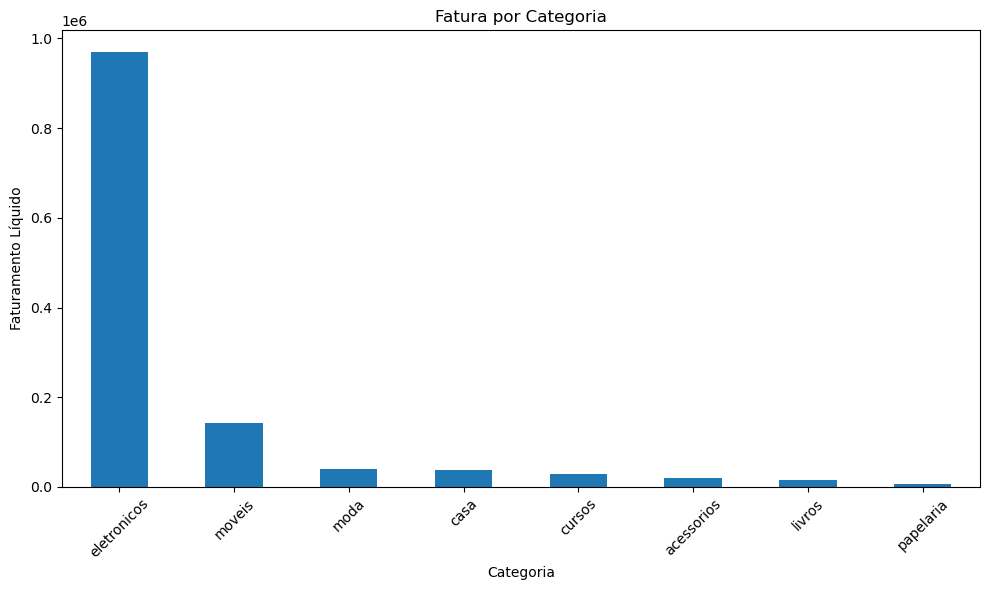

In [306]:
# Faturamento por categoria

plt.figure(figsize=(10,6))
faturamento_categoria.plot(kind='bar')
plt.title('Fatura por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Faturamento Líquido')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../graficos/faturamento_categoria.png', dpi=300, bbox_inches='tight')
plt.show()

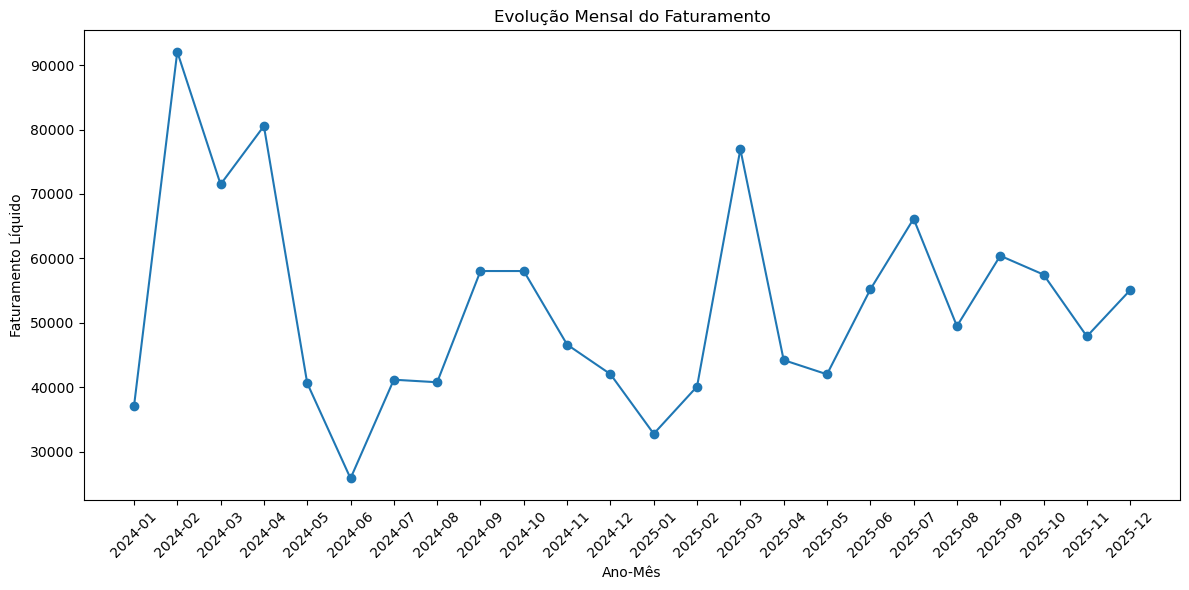

In [307]:
# Evolução da receita ao longo do tempo

receita_mensal.index = receita_mensal.index.astype(str)

plt.figure(figsize=(12,6))
plt.plot(receita_mensal.index, receita_mensal.values, marker='o')
plt.title('Evolução Mensal do Faturamento')
plt.xlabel('Ano-Mês')
plt.ylabel('Faturamento Líquido')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../graficos/receita_mensal.png', dpi=300, bbox_inches='tight')
plt.show()

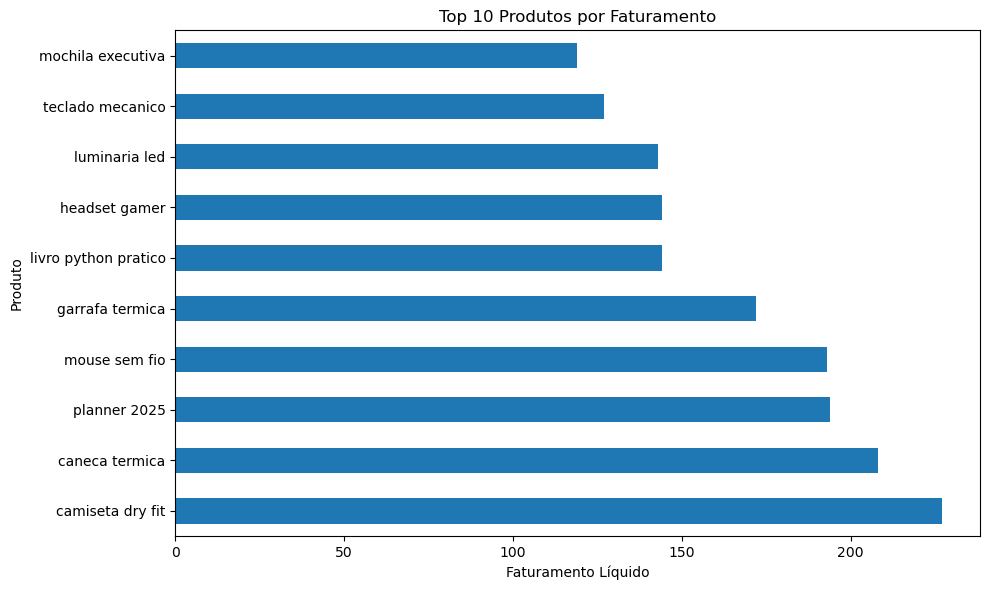

In [308]:
# Top 10 produtos mais vendidos

plt.figure(figsize=(10,6))
top_produtos.plot(kind='barh')
plt.title('Top 10 Produtos por Faturamento')
plt.xlabel('Faturamento Líquido')
plt.ylabel('Produto')
plt.tight_layout()
plt.savefig('../graficos/top_produtos.png', dpi=300, bbox_inches='tight')
plt.show()

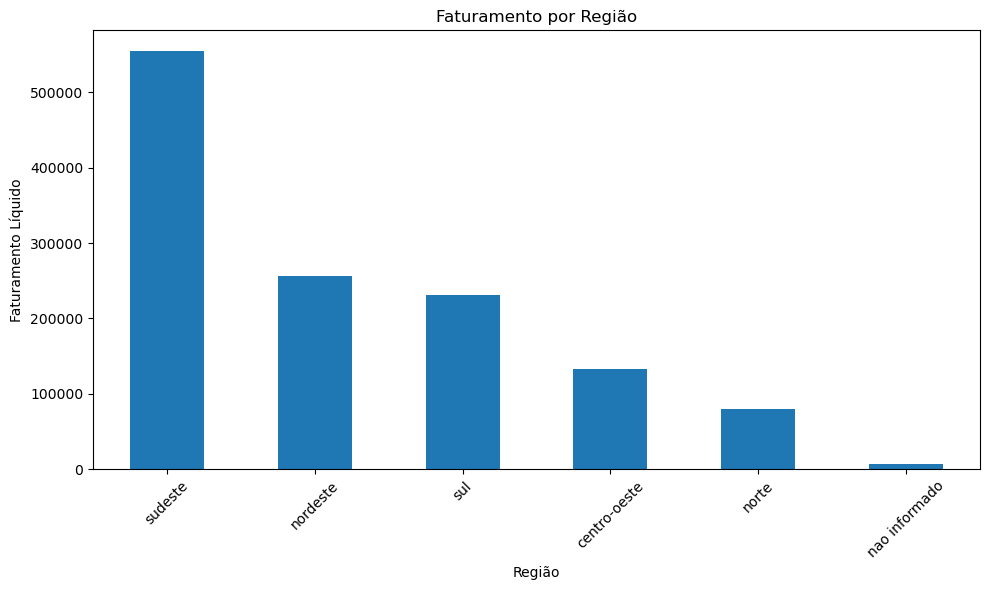

In [309]:
# Faturamento por região

plt.figure(figsize=(10,6))
faturamento_regiao.plot(kind='bar')
plt.title('Faturamento por Região')
plt.xlabel('Região')
plt.ylabel('Faturamento Líquido')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../graficos/faturamento_regiao.png', dpi=300, bbox_inches='tight')
plt.show()

## Principais Insights

- A categoria de eletrônicos liderou o faturamento total.
- A região Sudeste apresentou melhor desempenho.
- O mês de Janeiro de 2024 registrou pico de vendas.
- O mês de Junho de 2024 registrou o pior momento de vendas.
- Alguns produtos possuem baixa representatividade e podem ser reavaliados.